# **Fundamentos de aprendizaje por refuerzo**
## **Redes neuronales (Regularización)**

### Arquitectura típica de una red neuronal

|**Hiperparámetro**|**Valor típico**|
| --- | --- |
| Forma de la capa de entrada | La misma forma que el número de características (por ejemplo, 3 para # dormitorios, # baños, # plazas de coche en la predicción del precio de la vivienda).
| Capa(s) oculta(s)|Específico del problema, mínima = 1, máxima = ilimitada
| Neuronas por capa oculta | Específico del problema, generalmente de 10 a 100.
| Forma de la capa de salida | La misma forma que la forma de predicción deseada (por ejemplo, 1 para el precio de la vivienda).
| Activación oculta | Usualmente [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (unidad lineal rectificada).
| Activación de salida | Ninguna, ReLU, logística/tanh
| Función de pérdida | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (error cuadrático medio) o [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (error absoluto medio)/Huber (combinación de MAE/MSE) si hay valores atípicos.
| Optimizador | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (descenso de gradiente estocástico), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |

*Tabla 1: Arquitectura típica de una red*

🔑 **Nota:** Un **hiperparámetro** en aprendizaje automático es algo que un analista de datos o desarrollador puede establecer por sí mismo, mientras que un **parámetro** normalmente describe algo que un modelo aprende por sí mismo (un valor no establecido explícitamente por un analista).

## Librerías

In [1]:
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
dataset_path = keras.utils.get_file("auto-mpg.data", "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

      0/Unknown 0s 0s/step

### El set de Datos de MPG

El set de datos esta disponible en el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/)

In [4]:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight',
                'Acceleration', 'Model Year', 'Origin']
raw_dataset = pd.read_csv(dataset_path, names=column_names,
                      na_values = "?", comment='\t',
                      sep=" ", skipinitialspace=True)

dataset = raw_dataset.copy()
dataset.head(398)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


### Limpiar la data

Observar si el conjunto de datos tiene datos faltantes (`NaN`)

In [5]:
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
Origin,0


Observando lo anterior, se observar que la variable `Horsepower` tiene 6 datos faltantes.

A continuación se elimina los valores faltantes del dataset y se observa nuevamente si el conjunto de datos contiene datos faltantes para asegurarnos.

In [6]:
dataset = dataset.dropna()
dataset.isna().sum()
dataset.shape

(392, 8)

La columna de "Origin" realmente es categorica, no numerica. Entonces es conveniente convertirla a "one-hot":

In [7]:
origin = dataset.pop('Origin')
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0
dataset.head(398)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
0,18.0,8,307.0,130.0,3504.0,12.0,70,1.0,0.0,0.0
1,15.0,8,350.0,165.0,3693.0,11.5,70,1.0,0.0,0.0
2,18.0,8,318.0,150.0,3436.0,11.0,70,1.0,0.0,0.0
3,16.0,8,304.0,150.0,3433.0,12.0,70,1.0,0.0,0.0
4,17.0,8,302.0,140.0,3449.0,10.5,70,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1.0,0.0,0.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0.0,1.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1.0,0.0,0.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1.0,0.0,0.0


### Dividir la data en entrenamiento y prueba


Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

In [8]:
from sklearn.model_selection import train_test_split
train_dataset, test_dataset = train_test_split(dataset, train_size=0.8, random_state=0)

### Inspeccionar la data

Revisar la distribucion conjunta de un par de columnas de el set de entrenamiento.

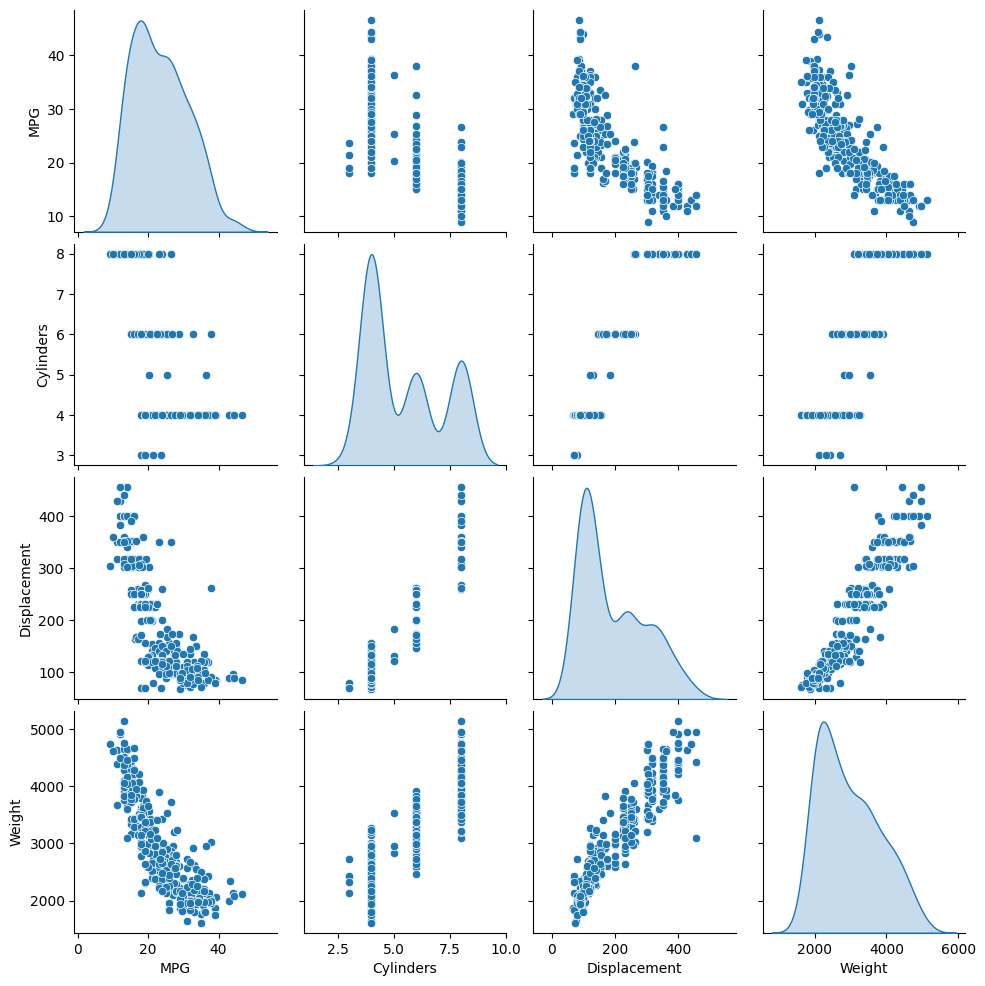

In [ ]:
sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde")

### Estadisticas generales de los datos

In [ ]:
train_stats = train_dataset.describe()
train_stats.pop("MPG")
train_stats = train_stats.transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
Cylinders,313.0,5.447284,1.690263,3.0,4.0,4.0,8.0,8.0
Displacement,313.0,192.787540,103.201153,68.0,105.0,151.0,260.0,455.0
Horsepower,313.0,104.009585,37.915348,46.0,78.0,95.0,120.0,230.0
Weight,313.0,2972.255591,841.134947,1613.0,2230.0,2815.0,3574.0,5140.0
Acceleration,313.0,15.560383,2.785476,8.0,13.6,15.5,17.0,24.8
Model Year,313.0,76.070288,3.660449,70.0,73.0,76.0,79.0,82.0
USA,313.0,0.623003,0.485410,0.0,0.0,1.0,1.0,1.0
Europe,313.0,0.169329,0.375643,0.0,0.0,0.0,0.0,1.0
Japan,313.0,0.207668,0.406287,0.0,0.0,0.0,0.0,1.0


### Separar las caracteristicas de las etiquetas

Separar el valor objetivo, o la "etiqueta" de las caracteristicas. Esta etiqueta es el valor que entrenara el modelo para predecir.

In [ ]:
train_labels = train_dataset.pop('MPG')
y_test = test_dataset.pop('MPG')

In [ ]:
y_train = train_labels.values
y_test = y_test.values

### Normalizar los datos

Revisando otra vez el bloque de train_stats que se presentó, se nota la diferencia de rangos de cada caracteristica.

Es una buena práctica normalizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo "podría" converger sin normalización de características, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [ ]:
def norm(x):
  return (x - train_stats['mean']) / train_stats['std']
normed_train_data = norm(train_dataset)
X_test_norm = norm(test_dataset)

In [ ]:
X_train_norm = normed_train_data.values
X_test_norm = X_test_norm.values

### Construir el modelo

Utilizaremos un modelo secuencial con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo. Los pasos de construcción del modelo se envuelven en una función, build_model, ya que crearemos un segundo modelo, más adelante.

In [ ]:
# Set random seed
tf.random.set_seed(0)

# Create a model using the sequential
num_features = len(train_dataset.keys())

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[num_features])) # Capa de entrada con número de neuronas igual al número de características
model.add(tf.keras.layers.Dense(64, activation='relu')) # 1era Capa oculta con 64 neuronas
model.add(tf.keras.layers.Dense(64, activation='relu')) # 2da Capa oculta con 64 neuronas
model.add(tf.keras.layers.Dense(1, activation='linear')) # Capa de salida con 1 neurona

# Compile the model
model.compile(loss=tf.keras.losses.mse, # mse is short for mean absolute error
              optimizer=tf.keras.optimizers.Adam(0.001), # RMSprop is the optimizer
              metrics=["mae","mse"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo

Entrenar el modelo durante 1000 épocas y registrar la precisión de entrenamiento y validación en el objeto history.

In [ ]:
historial = model.fit(X_train_norm, y_train, epochs=1000, validation_split = 0.2, verbose=1)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 565.8712 - mae: 22.6186 - mse: 565.8712 - val_loss: 575.9995 - val_mae: 22.6157 - val_mse: 575.9995
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 530.4786 - mae: 21.8645 - mse: 530.4786 - val_loss: 535.9232 - val_mae: 21.7705 - val_mse: 535.9232
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 490.8793 - mae: 20.9933 - mse: 490.8793 - val_loss: 487.4734 - val_mae: 20.7129 - val_mse: 487.4734
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 443.3745 - mae: 19.9048 - mse: 443.3745 - val_loss: 428.8646 - val_mae: 19.3683 - val_mse: 428.8646
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 386.0376 - mae: 18.5105 - mse: 386.0376 - val_loss: 359.2153 - val_mae: 17.6358 - val_mse: 359.2153
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 319.8059 - mae: 16.7414 - mse: 319.8059 - val_loss: 282.7766 - val_mae: 15.4815 - val_mse: 282.7766
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms

In [ ]:
pd.DataFrame(historial.history)

,loss,mae,mse,val_loss,val_mae,val_mse
0,4.721084,1.501695,4.721084,5.857193,1.907517,5.857193
1,4.717368,1.500241,4.717368,5.867060,1.909466,5.867060
2,4.713331,1.499573,4.713331,5.870587,1.910184,5.870587
3,4.706663,1.497628,4.706663,5.871886,1.909928,5.871886
4,4.701764,1.496919,4.701764,5.871315,1.908818,5.871315
...,...,...,...,...,...,...
95,4.272997,1.409437,4.272997,6.186995,1.941345,6.186995
96,4.269800,1.409640,4.269800,6.205838,1.944035,6.205838
97,4.264412,1.408532,4.264412,6.207568,1.942820,6.207568
98,4.260922,1.408251,4.260922,6.213376,1.943308,6.213376


In [ ]:
epoch = historial.epoch
loss = historial.history["loss"]
mae = historial.history["mae"]
val_mae = historial.history["val_mae"]
mse = historial.history["mse"]
val_mse = historial.history["val_mse"]

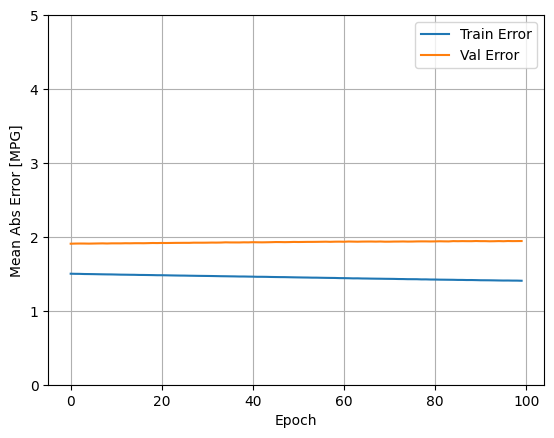

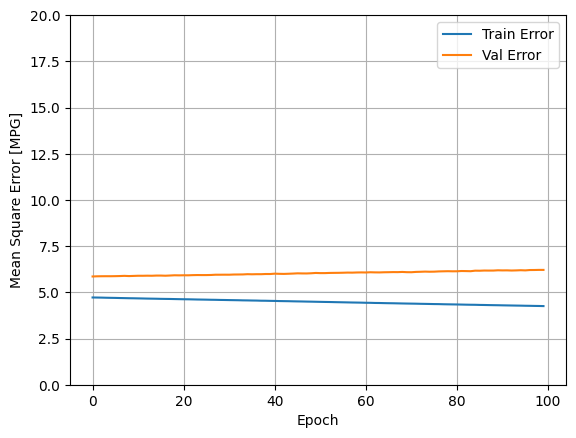

In [ ]:
plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Abs Error [MPG]')
plt.plot(epoch, mae, label='Train Error')
plt.plot(epoch, val_mae, label = 'Val Error')
plt.ylim([0,5])
plt.grid()
plt.legend()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Square Error [MPG]')
plt.plot(epoch, mse, label='Train Error')
plt.plot(epoch, val_mse, label = 'Val Error')
plt.ylim([0,20])
plt.grid()
plt.legend()

Este gráfico muestra poca mejora, o incluso degradación en el error de validación después de aproximadamente 100 épocas. Actualicemos la llamada `model.fit` para detener automáticamente el entrenamiento cuando el puntaje de validación no mejore. Utilizaremos **EarlyStopping** que pruebe una condición de entrenamiento para cada época. Si transcurre una cantidad determinada de épocas sin mostrar mejoría, entonces detiene automáticamente el entrenamiento.

Predicciones

In [ ]:
y_pred = model.predict(X_test_norm, verbose=0).flatten()

In [ ]:
y_pred

array([28.747122 , 24.757889 , 13.144391 , 37.276318 , 34.796253 ,
       19.248388 , 37.076008 , 31.227251 , 18.621706 , 26.890413 ,
       28.47214  , 14.888325 , 24.557264 , 13.708758 , 17.118414 ,
       33.3631   , 23.044573 , 14.115527 , 26.013023 , 26.838228 ,
       17.053625 , 15.835941 , 20.784784 , 23.958258 , 32.98496  ,
       13.3305435, 27.594921 , 26.470871 , 19.836985 , 14.42895  ,
       19.323614 , 32.959526 , 23.694735 , 29.668661 , 19.126595 ,
       28.324038 , 30.890123 , 14.339725 , 15.179004 , 12.866538 ,
       15.21992  , 34.35722  , 31.217464 , 14.500422 , 30.546612 ,
       14.71593  , 29.322355 , 13.953707 , 16.239668 , 18.961535 ,
       26.400301 , 14.873458 , 12.573741 , 22.233881 , 32.730736 ,
       33.214    , 24.25037  , 19.968077 , 32.34862  , 23.659117 ,
       19.275248 , 28.129683 , 31.93835  , 13.100816 , 26.616117 ,
       16.320688 , 12.8747   , 28.934774 , 23.542412 , 35.980618 ,
       34.06441  , 31.178455 , 19.06357  , 15.284907 , 18.5680

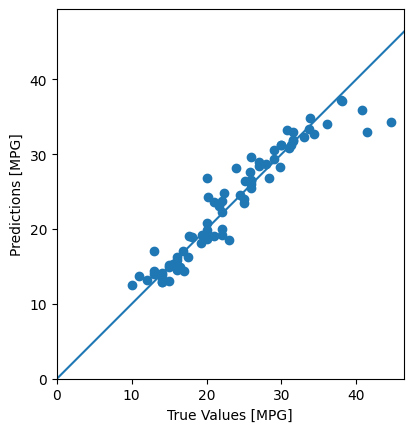

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])

Evaluación del modelo

Veamos qué tan bien generaliza el modelo al usar el conjunto **test**, que no usamos al entrenar el modelo. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real.

In [ ]:
loss, mae, mse = model.evaluate(X_test_norm, y_test, verbose=2)
print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

3/3 - 0s - 59ms/step - loss: 7.8107 - mae: 1.9713 - mse: 7.8107
Testing set Mean Abs Error:  1.97 MPG


Distribución de errores

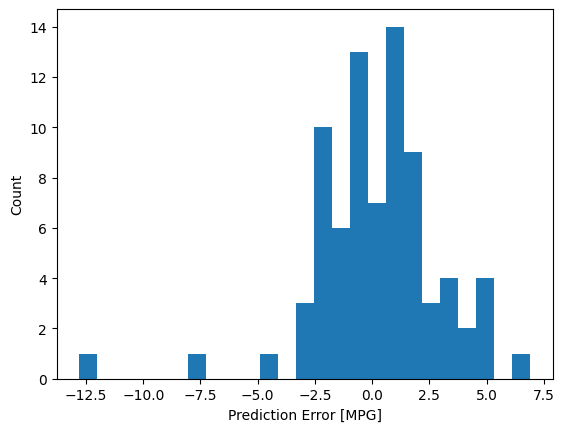

In [ ]:
error = y_pred - y_test
plt.hist(error, bins = 25)
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")

### **Early stopping**

In [ ]:
# Create a model using the sequential
tf.random.set_seed(1)
num_features = len(train_dataset.keys())
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[num_features]))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

# Compile the model
model.compile(loss=tf.keras.losses.mse,
              optimizer=tf.keras.optimizers.Adam(0.001),
              metrics=["mae","mse"])

# The patience parameter is the amount of epochs to check for improvement
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

historial = model.fit(normed_train_data, train_labels, epochs=1000, validation_split = 0.2, verbose=1, callbacks=[early_stop])

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 636.1332 - mae: 23.8646 - mse: 636.1332 - val_loss: 606.9413 - val_mae: 23.1541 - val_mse: 606.9413
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 603.1374 - mae: 23.1380 - mse: 603.1374 - val_loss: 572.7261 - val_mae: 22.3861 - val_mse: 572.7261
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 569.6432 - mae: 22.3745 - mse: 569.6432 - val_loss: 534.5778 - val_mae: 21.5097 - val_mse: 534.5778
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 531.6025 - mae: 21.4842 - mse: 531.6025 - val_loss: 488.5843 - val_mae: 20.4227 - val_mse: 488.5843
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 485.3563 - mae: 20.3684 - mse: 485.3563 - val_loss: 433.7163 - val_mae: 19.0661 - val_mse: 433.7163
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 429.6135 - mae: 18.9606 - mse: 429.6135 - val_loss: 369.7356 - val_mae: 17.3818 - val_mse: 369.7356
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

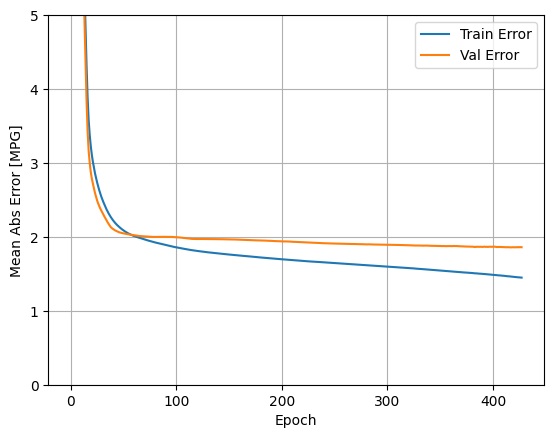

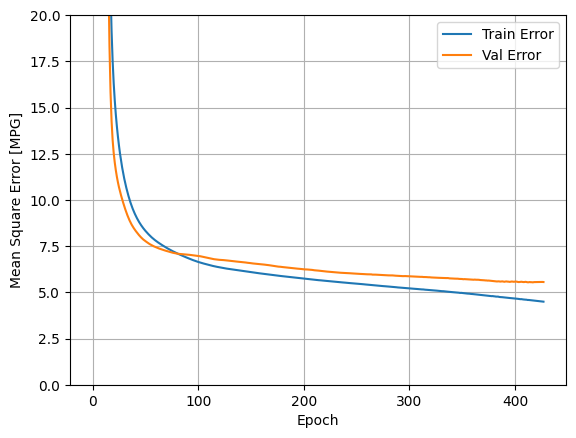

In [ ]:
epoch = historial.epoch
loss = historial.history["loss"]
mae = historial.history["mae"]
val_mae = historial.history["val_mae"]
mse = historial.history["mse"]
val_mse = historial.history["val_mse"]

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Abs Error [MPG]')
plt.plot(epoch, mae, label='Train Error')
plt.plot(epoch, val_mae, label = 'Val Error')
plt.ylim([0,5])
plt.grid()
plt.legend()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Square Error [MPG]')
plt.plot(epoch, mse, label='Train Error')
plt.plot(epoch, val_mse, label = 'Val Error')
plt.ylim([0,20])
plt.grid()
plt.legend()

Evaluación del modelo

In [ ]:
loss, mae, mse = model.evaluate(X_test_norm, y_test, verbose=2)
print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

3/3 - 0s - 41ms/step - loss: 6.0946 - mae: 1.7471 - mse: 6.0946
Testing set Mean Abs Error:  1.75 MPG


Predicciones


In [ ]:
y_pred = model.predict(X_test_norm).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


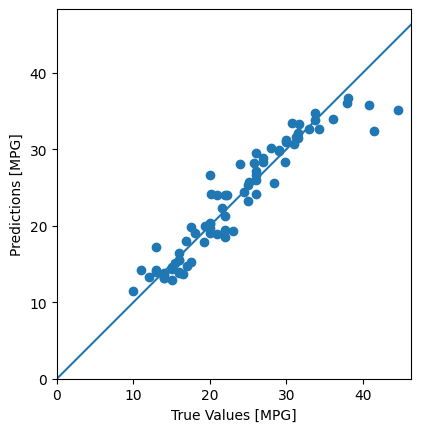

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])

Distribución de errores

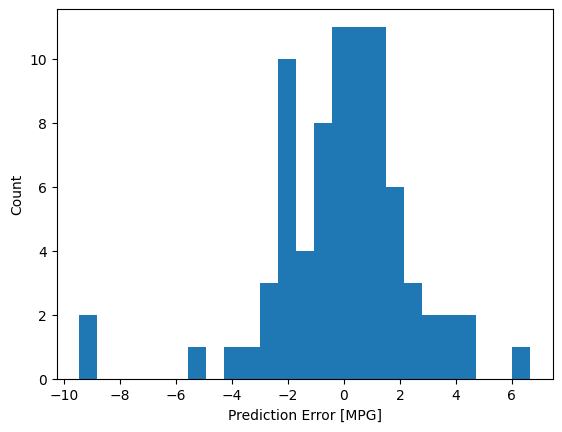

In [ ]:
error = y_pred - y_test
plt.hist(error, bins = 25)
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")

### **Regularization L1 and L2**



In [ ]:
# Set random seed
tf.random.set_seed(2)

# Create a model using the sequential
num_features = len(train_dataset.keys())

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[num_features])) # Capa de entrada con número de neuronas igual al número de características
model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.1))) # 1era Capa oculta con 64 neuronas
model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.1))) # 2da Capa oculta con 64 neuronas
model.add(tf.keras.layers.Dense(1, activation='linear')) # Capa de salida con 1 neurona

# Compile the model
model.compile(loss=tf.keras.losses.mse, # mse is short for mean absolute error
              optimizer=tf.keras.optimizers.Adam(0.001), # RMSprop is the optimizer
              metrics=["mae","mse"])

In [ ]:
historial = model.fit(X_train_norm, y_train, epochs=1000, validation_split = 0.2, verbose=0)

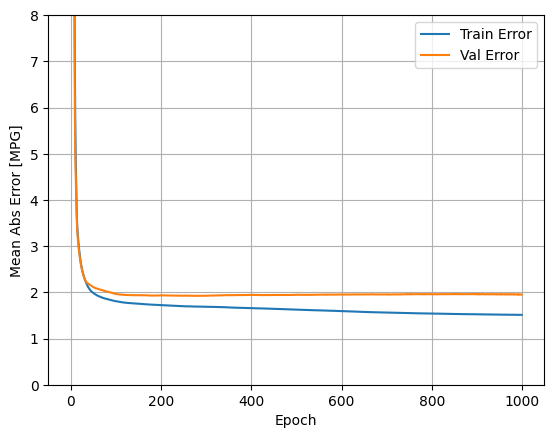

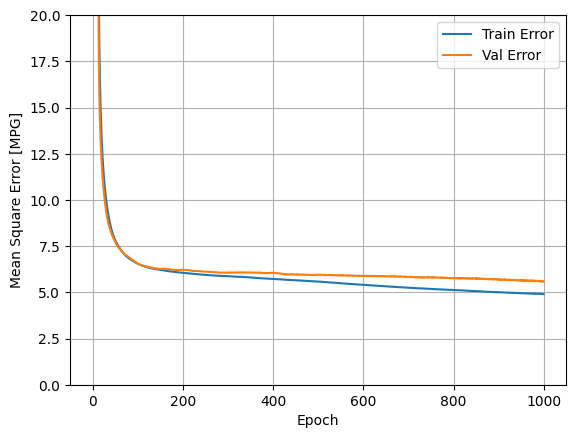

In [ ]:
epoch = historial.epoch
loss = historial.history["loss"]
mae = historial.history["mae"]
val_mae = historial.history["val_mae"]
mse = historial.history["mse"]
val_mse = historial.history["val_mse"]

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Abs Error [MPG]')
plt.plot(epoch, mae, label='Train Error')
plt.plot(epoch, val_mae, label = 'Val Error')
plt.ylim([0,8])
plt.grid()
plt.legend()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Square Error [MPG]')
plt.plot(epoch, mse, label='Train Error')
plt.plot(epoch, val_mse, label = 'Val Error')
plt.ylim([0,20])
plt.grid()
plt.legend()

In [ ]:
loss, mae, mse = model.evaluate(X_test_norm, y_test, verbose=2)
print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

3/3 - 0s - 79ms/step - loss: 8.4869 - mae: 1.7086 - mse: 6.1670
Testing set Mean Abs Error:  1.71 MPG


In [ ]:
y_pred = model.predict(X_test_norm).flatten()

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


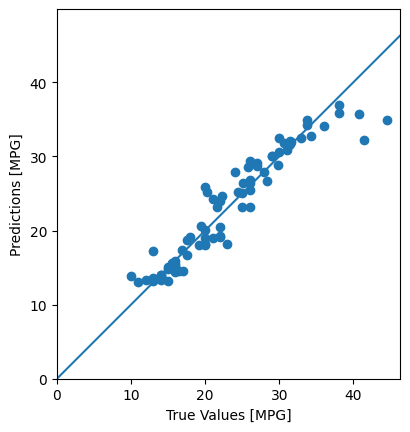

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])

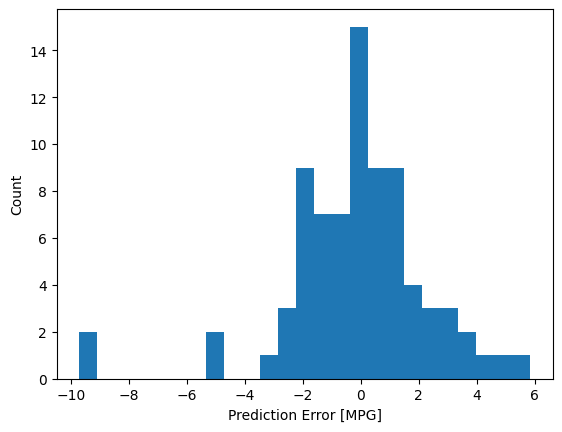

In [ ]:
error = y_pred - y_test
plt.hist(error, bins = 25)
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")

### **Dropout**

In [ ]:
# Set random seed
tf.random.set_seed(3)

# Create a model using the sequential
num_features = len(train_dataset.keys())

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[num_features])) # Capa de entrada con número de neuronas igual al número de características
model.add(tf.keras.layers.Dense(64, activation='relu')) # 1era Capa oculta con 128 neuronas
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.Dense(64, activation='relu')) # 2da Capa oculta con 128 neuronas
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.Dense(1)) # Capa de salida con 1 neurona

# Compile the model
model.compile(loss=tf.keras.losses.mse, # mse is short for mean absolute error
              optimizer=tf.keras.optimizers.Adam(0.001), # RMSprop is the optimizer
              metrics=["mae","mse"])

In [ ]:
historial = model.fit(X_train_norm, y_train, epochs=1000, validation_split = 0.2, verbose=1)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 494ms/step - loss: 572.0649 - mae: 22.7486 - mse: 572.0649 - val_loss: 577.8286 - val_mae: 22.6309 - val_mse: 577.8286
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 535.9580 - mae: 21.9537 - mse: 535.9580 - val_loss: 536.4280 - val_mae: 21.7218 - val_mse: 536.4280
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 495.9910 - mae: 21.0370 - mse: 495.9910 - val_loss: 488.3921 - val_mae: 20.6386 - val_mse: 488.3921
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 449.6661 - mae: 19.9509 - mse: 449.6661 - val_loss: 432.0290 - val_mae: 19.3095 - val_mse: 432.0290
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 399.3587 - mae: 18.6581 - mse: 399.3587 - val_loss: 366.3713 - val_mae: 17.6522 - val_mse: 366.3713
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 336.1726 - mae: 16.9379 - mse: 336.1726 - val_loss: 291.9286 - val_mae: 15.6336 - val_mse: 291.9286
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

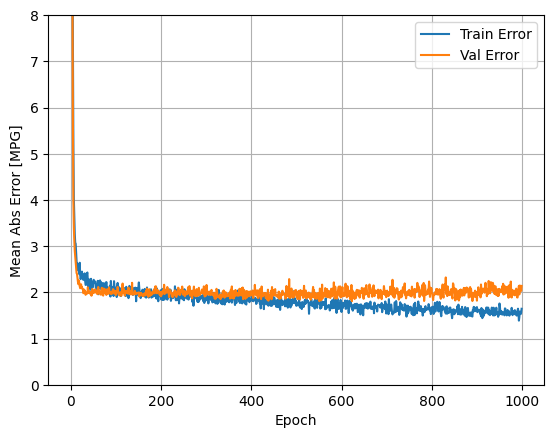

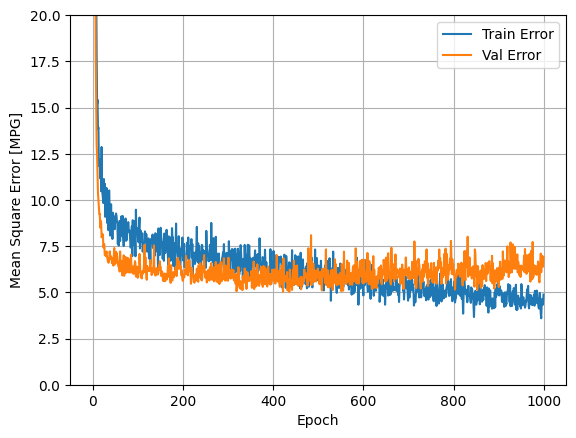

In [ ]:
epoch = historial.epoch
loss = historial.history["loss"]
mae = historial.history["mae"]
val_mae = historial.history["val_mae"]
mse = historial.history["mse"]
val_mse = historial.history["val_mse"]

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Abs Error [MPG]')
plt.plot(epoch, mae, label='Train Error')
plt.plot(epoch, val_mae, label = 'Val Error')
plt.ylim([0,8])
plt.grid()
plt.legend()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Square Error [MPG]')
plt.plot(epoch, mse, label='Train Error')
plt.plot(epoch, val_mse, label = 'Val Error')
plt.ylim([0,20])
plt.grid()
plt.legend()

In [ ]:
loss, mae, mse = model.evaluate(X_test_norm, y_test, verbose=2)
print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

3/3 - 0s - 12ms/step - loss: 6.1865 - mae: 1.8666 - mse: 6.1865
Testing set Mean Abs Error:  1.87 MPG


In [ ]:
y_pred = model.predict(X_test_norm).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


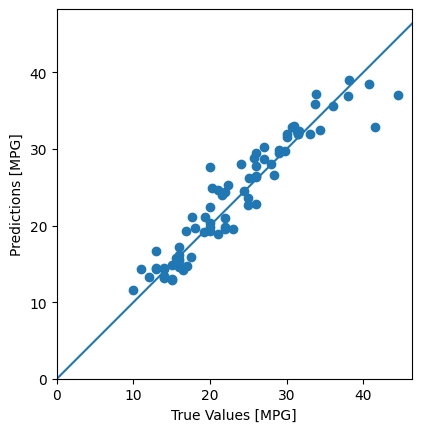

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])

In [ ]:
error = y_pred - y_test
plt.hist(error, bins = 25)
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")

# **Taller práctico**

- Crear un modelo de red neuronal para el conjunto de datos **Student Performance**. El objetivo es predecir el índice de rendimiento (`Performance Index`) de los estudiantes en función de sus características como:

  - Horas estudiadas (`Hours Studied`)
  - Notas anteriores (`Previous Scores`)
  - Actividades extraescolares (`Extracurricular Activities`)
    {Yes: 1,   No: 0}
  - Horas de sueño (`Sleep Hours`)
  - Ejemplos de exámenes practicados (`Sample Question Papers Practiced`)
- Agregar técnicas de regularización:
  1. Early stopping.
  2. L1 y L2
  3. Dropout
- Evaluar el modelo y comparar los resultados entre un **modelo sin regularización** vs un **modelo con regularización**.


In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

**Dataset**

In [ ]:
data = pd.read_csv(filepath_or_buffer="https://raw.githubusercontent.com/cdavid2804/test-1/main/StudentPerformance.csv")
data['Extracurricular Activities'] = data['Extracurricular Activities'].replace({'Yes': 1, 'No': 0})
print(np.shape(data))
data.sample(10)

(10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
567,7,67,1,5,0,59.0
5030,7,45,0,7,5,36.0
5538,2,69,0,8,3,49.0
9575,3,81,1,9,3,59.0
7910,3,40,1,5,2,18.0
8825,3,63,1,4,9,42.0
6150,8,70,0,4,6,63.0
5171,8,87,0,7,6,82.0
5703,6,68,0,9,7,57.0
5020,6,88,0,4,6,75.0
